<a href="https://colab.research.google.com/github/Hanu175/CSL701_CS40_Machine-Learning-Lab/blob/main/Experiments/MLExp02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Vedant Vinay Paste

Roll No : CS-40

Batch : CS-03


Aim : To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

Task 1: Import libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")


Task 2: LOAD AUTO MPG DATASET

In [4]:
# If the CSV is uploaded to Google Colab:
from google.colab import files
upload = files.upload()

df = pd.read_csv("auto-mpg.csv")

print("Dataset loaded successfully!")
print(df.head())

Saving auto-mpg.csv to auto-mpg.csv
Dataset loaded successfully!
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


Task 3: INSPECT AND CLEAN DATA

In [5]:
print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())


# Convert horsepower to numeric
# Some versions of Auto MPG contain '?' instead of numbers
df["horsepower"] = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
)

# Remove rows with missing horsepower
df = df.dropna(subset=["horsepower"])

print("\nShape after cleaning:")
print(df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())



Dataset Shape:
(398, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Summary Statistics:
              mpg   cylinders  displacement       weight  acceleration  \
count  398.000000  398.000

Task 4: SELECT HORSEPOWER AND MPG

In [6]:
X = df["horsepower"].to_numpy()
y = df["mpg"].to_numpy()

print("\nHorsepower:")
print(X[:10])

print("\nMPG:")
print(y[:10])


Horsepower:
[130. 165. 150. 150. 140. 198. 220. 215. 225. 190.]

MPG:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]


Task 5: PLOT SCATTER GRAPH

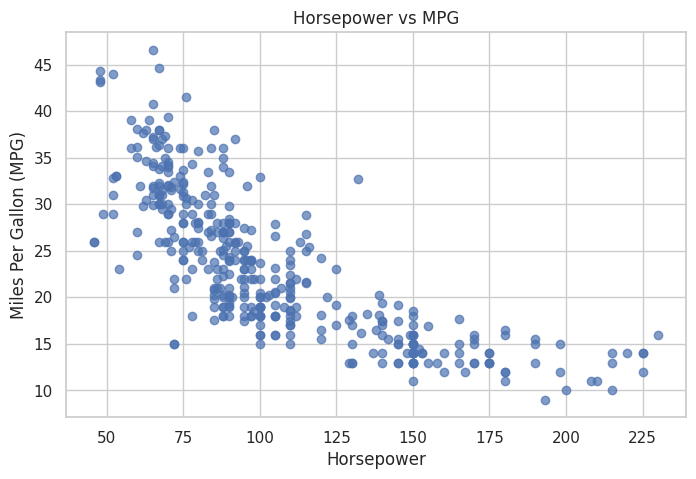

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, alpha=0.7)

plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("Miles Per Gallon (MPG)")

plt.show()


Task 6: ADD BIAS TERM


In [8]:
# Add a column of 1s for the intercept/bias term
X_bias = np.column_stack((np.ones(len(X)), X))

print("\nFirst 5 rows after adding bias:")
print(X_bias[:5])


First 5 rows after adding bias:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


Task 7:COMPUTE CORRELATION

In [9]:
correlation = np.corrcoef(X, y)[0, 1]

print("\nCorrelation between Horsepower and MPG:")
print(correlation)



Correlation between Horsepower and MPG:
-0.7784267838977756


Task 8: CALCULATE OLS WEIGHTS

In [10]:
# OLS equation:
#
# beta = (X^T X)^(-1) X^T y
#
# np.linalg.inv() calculates the matrix inverse

beta = np.linalg.inv(
    X_bias.T @ X_bias
) @ X_bias.T @ y

intercept = beta[0]
slope = beta[1]

print("\nOLS Weights:")
print("Intercept:", intercept)
print("Slope:", slope)

print("\nRegression Equation:")
print(f"MPG = {intercept:.4f} + ({slope:.4f} × Horsepower)")


OLS Weights:
Intercept: 39.9358610211705
Slope: -0.15784473335365387

Regression Equation:
MPG = 39.9359 + (-0.1578 × Horsepower)


Task 9: PREDICT VALUES

In [11]:
y_pred = X_bias @ beta

print("\nFirst 10 Actual MPG:")
print(y[:10])

print("\nFirst 10 Predicted MPG:")
print(y_pred[:10])


First 10 Actual MPG:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]

First 10 Predicted MPG:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


Task 10:  COMPUTE RESIDUALS

In [12]:
# Residual = Actual value - Predicted value

residuals = y - y_pred

print("\nFirst 10 Residuals:")
print(residuals[:10])



First 10 Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


Task 11: CALCULATE SSE, MSE AND R²

In [13]:
# SSE = Sum of Squared Errors
SSE = np.sum(residuals ** 2)

# MSE = Mean Squared Error
MSE = np.mean(residuals ** 2)

# R²
SS_total = np.sum((y - np.mean(y)) ** 2)

R2 = 1 - (SSE / SS_total)

print("\nModel Performance:")
print("--------------------------------")
print("SSE:", SSE)
print("MSE:", MSE)
print("R²:", R2)



Model Performance:
--------------------------------
SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348


Task 12: PLOT RESIDUAL GRAPH

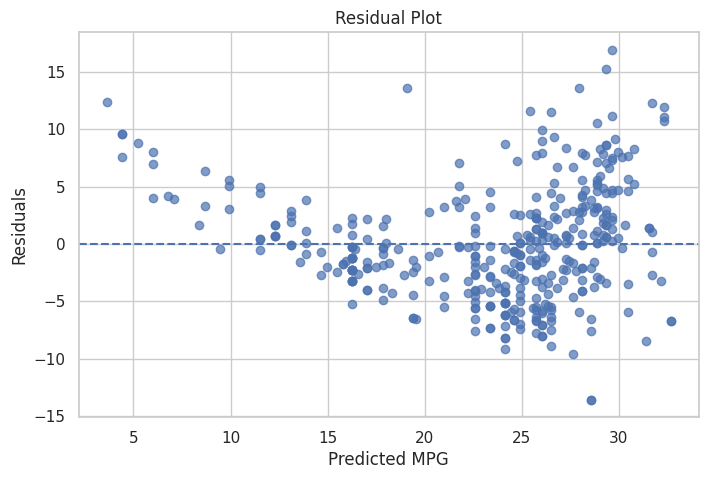

In [14]:

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

# Zero residual reference line
plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")

plt.show()


Task 13: INTERPRET RESULTS

In [15]:
print("\n================ RESULT INTERPRETATION ================")

print(f"""
1. Correlation:
   {correlation:.4f}

2. Intercept:
   {intercept:.4f}

3. Slope:
   {slope:.4f}

4. SSE:
   {SSE:.4f}

5. MSE:
   {MSE:.4f}

6. R²:
   {R2:.4f}
""")

if correlation < 0:
    print(
        "There is a negative relationship between horsepower "
        "and MPG."
    )
else:
    print(
        "There is a positive relationship between horsepower "
        "and MPG."
    )

if R2 >= 0.7:
    print(
        "The model explains a relatively large proportion "
        "of the variation in MPG."
    )
elif R2 >= 0.4:
    print(
        "The model explains a moderate proportion "
        "of the variation in MPG."
    )
else:
    print(
        "The model explains a relatively small proportion "
        "of the variation in MPG."
    )

print(
    f"\nFor every 1-unit increase in horsepower, "
    f"the predicted MPG changes by approximately "
    f"{abs(slope):.4f} MPG."
)

print("The experiment successfully implemented Simple Linear Regression using OLS."
      "Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.")


================ RESULT INTERPRETATION ================

1. Correlation:
   -0.7784

2. Intercept:
   39.9359

3. Slope:
   -0.1578

4. SSE:
   9385.9159

5. MSE:
   23.9437

6. R²:
   0.6059

There is a negative relationship between horsepower and MPG.
The model explains a moderate proportion of the variation in MPG.

For every 1-unit increase in horsepower, the predicted MPG changes by approximately 0.1578 MPG.
The experiment successfully implemented Simple Linear Regression using OLS.Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.


Task 14: SAVE RESULTS / PREPARE FOR GITHUB

In [16]:
# Save cleaned dataset
df.to_csv("auto-mpg-cleaned.csv", index=False)

print("\nCleaned dataset saved as auto-mpg-cleaned.csv")
print("\nNotebook is ready to upload to GitHub.")


Cleaned dataset saved as auto-mpg-cleaned.csv

Notebook is ready to upload to GitHub.
